<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Fase II: Implementación algorítmica y solver ODE</h3>

En esta fase se implementa un entorno modular para simular el problema <i>N-body</i> gravitacional en 3D, incluyendo:

<ul>
  <li>Aceleración gravitacional vectorial.</li>
  <li>Integrador RK4.</li>
  <li>Integrador simpléctico (Leapfrog / Velocity-Verlet).</li>
  <li>Bucle de simulación con registro temporal de energía y momento angular.</li>
</ul>

</div>

In [2]:
import numpy as np    #calculos numericos
import matplotlib.pyplot as plt #construir gráficas y visualizar los resultados de la simulación

G = 6.67430e-11  # m^3 kg^-1 s^-2 #constante de gravitación universal


In [3]:
def compute_accelerations(positions, masses, softening=0.0):  #la función calcula la aceleración total que experimenta cada cuerpo debido a la atracción gravitacional de todos los demás. 
    n = positions.shape[0]    #softening parámetro opcional que suaviza la interacción a distancias muy pequeñas   #número total de cuerpos del sistema.
    acc = np.zeros_like(positions, dtype=float)  #crea un arreglo vacío donde se almacenará la aceleración de cada cuerpo en las tres coordenadas espaciales
    for i in range(n):   #Recorre cada cuerpo del sistema para calcular la aceleración que recibe        
        r_ij = positions - positions[i]       # Calcula los vectores relativos desde el cuerpo i hacia todos los del sistema
        dist2 = np.sum(r_ij * r_ij, axis=1) + softening**2      #Calcula la distancia al cuadrado entre el cuerpo i y todos los demas
        inv_dist3 = np.zeros(n)  #es un arreglo auxiliar para 1/r3 , es de la ley gravitacional vectorial 
        mask = dist2 > 0    #Evita dividir por cero en el caso del cuerpo consigo mismo
        inv_dist3[mask] = dist2[mask]**(-1.5)     #esto es lo mas importante de toda la simulación, porque la aceleración determina cómo cambian las velocidades y posiciones con el tiempo
        weights = G * masses * inv_dist3
        acc[i] = np.sum(r_ij * weights[:, None], axis=0)
    return acc

def total_energy(positions, velocities, masses):    #Esta función calcula la energía mecánica total del sistema, sumando la energía cinética y la energía potencial gravitacional
    kinetic = 0.5 * np.sum(masses * np.sum(velocities**2, axis=1))
    potential = 0.0
    n = len(masses)
    for i in range(n):
        for j in range(i+1, n):
            r = np.linalg.norm(positions[j] - positions[i])
            potential -= G * masses[i] * masses[j] / r
    return kinetic + potential

def total_angular_momentum(positions, velocities, masses):   #momento angular total del sistema.
    return np.sum(np.cross(positions, masses[:, None] * velocities), axis=0)


In [4]:
def step_rk4(r, v, masses, dt):     #Runge-Kutta de cuarto orden
    a1 = compute_accelerations(r, masses)  #Calcula la aceleración en el estado actual
    k1r, k1v = v, a1  #Define la primera pendiente: para posición, la pendiente es la velocidad..para velocidad, la pendiente es la aceleración.

    a2 = compute_accelerations(r + 0.5*dt*k1r, masses) #evaluamos la aceleración en un punto intermedio, estimando primero una posición intermedia.
    k2r, k2v = v + 0.5*dt*k1v, a2  #Calcula la segunda pendiente usando esa estimació

    a3 = compute_accelerations(r + 0.5*dt*k2r, masses)  #evalua en otro punto intermedio, ahora con la segunda pendiente.
    k3r, k3v = v + 0.5*dt*k2v, a3  #Calcula la tercera pendiente

    a4 = compute_accelerations(r + dt*k3r, masses) #evalúa la aceleración en el extremo final del paso temporal
    k4r, k4v = v + dt*k3v, a4  #4ta pendiente

    r_next = r + (dt/6.0)*(k1r + 2*k2r + 2*k3r + k4r) #se combinan las 4 pendientes con los pesos clasicos , aproxi 4 
    v_next = v + (dt/6.0)*(k1v + 2*k2v + 2*k3v + k4v)
    return r_next, v_next

def step_leapfrog(r, v, masses, dt):   #método Leapfrog actualiza primero la velocidad a medio paso, luego la posición completa, y finalmente la velocidad al siguiente medio paso
    a0 = compute_accelerations(r, masses)
    v_half = v + 0.5*dt*a0
    r_next = r + dt*v_half
    a1 = compute_accelerations(r_next, masses)
    v_next = v_half + 0.5*dt*a1
    return r_next, v_next


In [5]:
def simulate(positions0, velocities0, masses, dt, n_steps, integrator="rk4"):  #Esta función ejecuta la integración temporal del sistema.
    step_fn = step_rk4 if integrator == "rk4" else step_leapfrog #Aquí se selecciona automáticamente el método de integración.

    n_bodies = len(masses) #Determina cuántos cuerpos tiene el sistema
    positions = np.zeros((n_steps+1, n_bodies, 3))    #Aquí se crean los arreglos donde se guardará la evolución temporal del sistema.
    velocities = np.zeros((n_steps+1, n_bodies, 3))
    energies = np.zeros(n_steps+1)   #energia total del sistema
    angmom = np.zeros((n_steps+1, 3))  #momento angular
    time = np.arange(n_steps+1) * dt  #vector temporal de simulación

    r = positions0.copy()   #Se copian las posiciones y velocidades iniciales para evitar modificar directamente las variables originales
    v = velocities0.copy()

    positions[0] = r    #Se registra el estado del sistema en el tiempo inicia
    velocities[0] = v
    energies[0] = total_energy(r, v, masses)
    angmom[0] = total_angular_momentum(r, v, masses)

    for k in range(1, n_steps+1):   #Este bucle recorre todos los pasos temporales de la simulación
        r, v = step_fn(r, v, masses, dt)  #Aquí se aplica el integrador seleccionado para calcular el nuevo estado del sistema
        positions[k] = r
        velocities[k] = v
        energies[k] = total_energy(r, v, masses)
        angmom[k] = total_angular_momentum(r, v, masses)

    return {"time": time, "positions": positions, "velocities": velocities, "energy": energies, "angular_momentum": angmom} #La función devuelve un dicci con todos los resultados de la simulación


In [8]:
#Tierra-satélite
M_EARTH = 5.97219e24   #se definen las masas del sistema
M_SAT = 4.19e5   #La masa del satélite se asumió como 4.19×105 𝑘𝑔 4.19×105kg, consistente con el orden de magnitud de satélites grandes en órbita baja

r_earth = np.array([0.0, 0.0, 0.0]) #La Tierra se coloca en el origen del sistema de coordenadas y se considera inicialmente en reposo.
v_earth = np.array([0.0, 0.0, 0.0])

alt = 420e3 #altitud orbital del satélite
r_orbit = 6371e3 + alt   #radio terrestre
v_circ = np.sqrt(G * M_EARTH / r_orbit) # Se calcula la velocidad necesaria para una órbita circular

incl = np.deg2rad(7.0)  # inclinación 7, se tomo asi como ref para que no fuera una orbita coplanar y observar los efectos fuera del plano 
r_sat = np.array([r_orbit, 0.0, 0.0])  #El satélite se coloca inicialmente sobre el eje x, a una distancia igual al radio orbital.
v_sat = np.array([0.0, v_circ*np.cos(incl), v_circ*np.sin(incl)]) #Esto genera una órbita ligeramente inclinada


positions0 = np.vstack([r_earth, r_sat]) #posiciones iniciales de todos los cuerpos
velocities0 = np.vstack([v_earth, v_sat]) #velocidades iniciales
masses = np.array([M_EARTH, M_SAT]) #masas correspondientes

dt = 10.0 #paso temporal 10 seg
n_steps = int(2*86400/dt) #Se simuló un intervalo de 2 días como tiempo suficiente para observar la evolución y estabilidad
res = simulate(positions0, velocities0, masses, dt, n_steps, integrator="rk4") #Se ejecuta la simulación usando el método Runge-Kutta de cuarto orden (RK4)

print("Simulación Fase 2 completada.") #Finalmente se imprime la energía total al inicio y al final de la simulación
print("Energía inicial:", res["energy"][0])
print("Energía final  :", res["energy"][-1])


Simulación Fase 2 completada.
Energía inicial: -12296729976014.578
Energía final  : -12296729988183.613


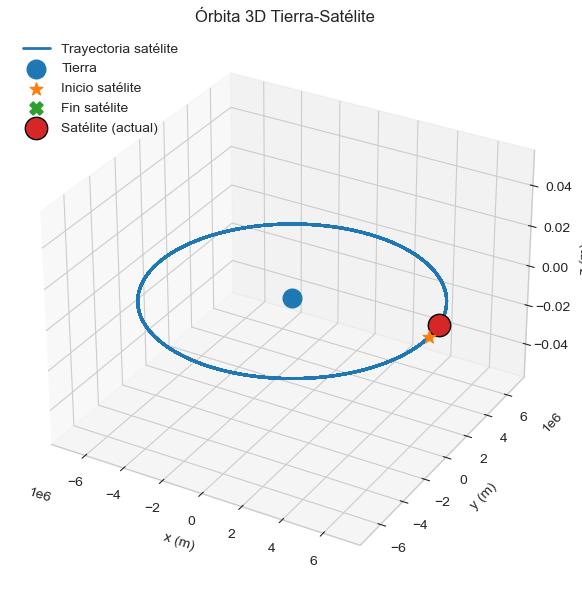

=== Evidencia de vectorización 3D ===
Forma de positions: (17281, 2, 3)
Forma de velocities: (17281, 2, 3)

Ejemplo vector posición (satélite, t0): [6791000.       0.       0.]
Ejemplo vector velocidad (satélite, t0): [   0.         7661.30592506    0.        ]

Componentes 3D activas en el código:
- Posición: [x, y, z]
- Velocidad: [vx, vy, vz]

|z| máximo del satélite en simulación: 0.000000e+00 m
|vz| máximo del satélite en simulación: 0.000000e+00 m/s

✅ Cumple: actualizaciones vectorizadas en 3D para posición y velocidad.


In [29]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d") #creamos trayectorias espaciales en x, y ,z 

p = res["positions"]  #se accede al arreglo que contiene las posiciones de todos los cuerpos durante toda la simulación

ax.plot(p[:,1,0], p[:,1,1], p[:,1,2], lw=2, label="Trayectoria satélite") #Se grafica la trayectoria del satélite en el espacio tridimensional, x,y,z.

# Tierra
ax.scatter(0, 0, 0, s=180, label="Tierra") #Esto permite visualizar la órbita del satélite alrededor del planeta

# Satélite inicio, fin y actual (visible) Se marcan tres posiciones importantes:
ax.scatter(p[0,1,0],  p[0,1,1],  p[0,1,2],  s=90,  marker="*", label="Inicio satélite") 
ax.scatter(p[-1,1,0], p[-1,1,1], p[-1,1,2], s=90,  marker="X", label="Fin satélite")
ax.scatter(p[-1,1,0], p[-1,1,1], p[-1,1,2], s=260, marker="o", edgecolors="black", label="Satélite (actual)")

ax.set_xlabel("x (m)") #Se etiquetan los ejes espaciales en metros, manteniendo consistencia con el Sistema Internacional.
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title("Órbita 3D Tierra-Satélite") #Se añade un título descriptivo y una leyenda para identificar los elementos de la figura.
ax.legend(loc="upper left")
plt.tight_layout() #evitar superposición de elementos
plt.show()

#vectorización 3D (posición y velocidad)

print("=== Evidencia de vectorización 3D ===") #Esto permite comprobar la estructura de los datos
print("Forma de positions:", res["positions"].shape)
print("Forma de velocities:", res["velocities"].shape)

print("\nEjemplo vector posición (satélite, t0):", res["positions"][0, 1, :]) #Se muestran ejemplos concretos de los vectores tridimensionales de posición y velocidad del satélite
print("Ejemplo vector velocidad (satélite, t0):", res["velocities"][0, 1, :])

print("\nComponentes 3D activas en el código:") #Esto confirma que cada estado del sistema está descrito por tres componentes espaciales.
print("- Posición: [x, y, z]") 
print("- Velocidad: [vx, vy, vz]")

z_abs_max = np.max(np.abs(res["positions"][:, 1, 2])) #Se calcula el valor máximo de z en velocidad y posición
vz_abs_max = np.max(np.abs(res["velocities"][:, 1, 2]))
print(f"\n|z| máximo del satélite en simulación: {z_abs_max:.6e} m")
print(f"|vz| máximo del satélite en simulación: {vz_abs_max:.6e} m/s")

if res["positions"].shape[2] == 3 and res["velocities"].shape[2] == 3:   #Se verifica que los arreglos tengan tres componentes espaciales.
    print("\n✅ Cumple: actualizaciones vectorizadas en 3D para posición y velocidad.")
else:
    print("\n❌ No cumple: revisar dimensiones.")



In [16]:

t = res["time"] #Se extrae el vector de tiempo de la simulación.
pos = res["positions"][:, 1, :] #se extraen las posiciones del satélite durante toda la simulación
vel = res["velocities"][:, 1, :] #Se obtiene el vector velocidad del satélite en cada instante de tiempo
E = res["energy"] #Se extrae la energía mecánica total del sistema en cada paso temporal
Lvec = res["angular_momentum"] #Se obtiene el vector de momento angular total del sistema en cada instante.

x, y, z = pos[:,0], pos[:,1], pos[:,2] #Se separan las componentes espaciales del satélite
vx, vy, vz = vel[:,0], vel[:,1], vel[:,2] #Se separan las componentes del vector velocidad.
vnorm = np.sqrt(vx**2 + vy**2 + vz**2) #Se calcula la norma del vector velocidad,representa la rapidez orbital del satélite

Lx, Ly, Lz = Lvec[:,0], Lvec[:,1], Lvec[:,2] #Se separan las componentes del vector de momento angular total del sistema
Lnorm = np.sqrt(Lx**2 + Ly**2 + Lz**2) #Se calcula la magnitud del momento angular


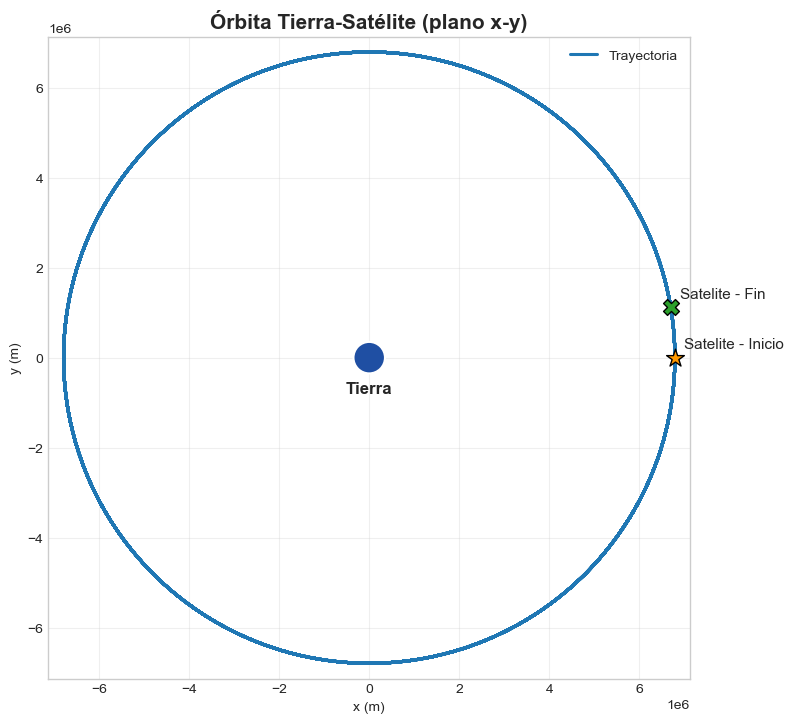

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(8, 8))

# Trayectoria del satélite
ax.plot(x, y, color="#1f77b4", lw=2.2, label="Trayectoria")

# Tierra (planeta)
earth_radius_plot = 3.5e5  # solo visual, no físico
earth = Circle((0, 0), earth_radius_plot, facecolor="#1f4fa3", edgecolor="white", lw=1.5, zorder=5)
ax.add_patch(earth)
ax.text(0, -7.0e5, "Tierra", ha="center", va="center", fontsize=12, fontweight="bold")

# Satélite: inicio y fin
ax.scatter(x[0], y[0], s=180, marker="*", color="#ff9900", edgecolor="black", zorder=6)
ax.text(x[0] + 2e5, y[0] + 2e5, "Satelite - Inicio", fontsize=11)

ax.scatter(x[-1], y[-1], s=130, marker="X", color="#2ca02c", edgecolor="black", zorder=6)
ax.text(x[-1] + 2e5, y[-1] + 2e5, "Satelite - Fin", fontsize=11)

# Formato
ax.set_title("Órbita Tierra-Satélite (plano x-y)", fontsize=15, weight="bold")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.3)

pad = 0.05 * np.max(np.sqrt(x**2 + y**2))
ax.set_xlim(x.min()-pad, x.max()+pad)
ax.set_ylim(y.min()-pad, y.max()+pad)

# Leyenda simple
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


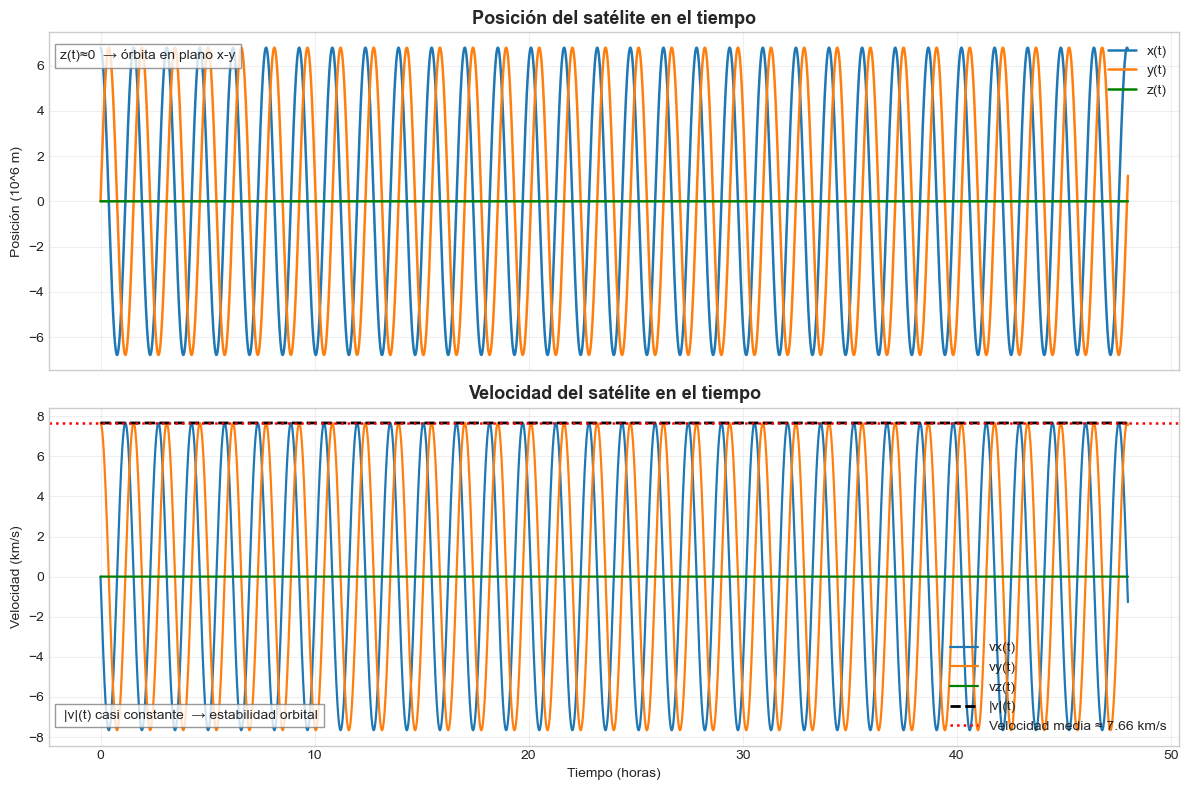

Periodo orbital teórico aproximado: 92.82 min
Velocidad media simulada: 7.661 km/s


In [22]:
# Figura 2: posición y velocidad
T_orbita = 2*np.pi*np.sqrt((r_orbit**3)/(G*M_EARTH))  #Se calcula el periodo orbital esperado usando la relación de la mecánica celeste
v_prom = np.mean(vnorm) #Se calcula la velocidad media del satélite durante la simulación a partir de la norma del vector velocidad

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True) #Se construye una figura con dos gráficos, evolución temporal de posicion y velocidad

# Posición
ax[0].plot(t/3600, x/1e6, label="x(t)", lw=1.8)  #Se representan las componentes de la posición en función del tiempo, horas a tiempo , mill de m para poscisión
ax[0].plot(t/3600, y/1e6, label="y(t)", lw=1.8)
ax[0].plot(t/3600, z/1e6, label="z(t)", lw=1.8, color="green")
ax[0].set_title("Posición del satélite en el tiempo", fontsize=13, weight="bold")
ax[0].set_ylabel("Posición (10^6 m)")
ax[0].legend(loc="upper right")
ax[0].grid(alpha=0.3)
ax[0].text(0.01, 0.92, "z(t)≈0  → órbita en plano x-y", transform=ax[0].transAxes, #destaca que la componente z permanece muy cercana a cero
           bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"))

# Velocidad
ax[1].plot(t/3600, vx/1000, label="vx(t)", lw=1.6) #Se representan las componentes de la velocidad en km/s
ax[1].plot(t/3600, vy/1000, label="vy(t)", lw=1.6)  #También se grafica la magnitud total de la velocidad
ax[1].plot(t/3600, vz/1000, label="vz(t)", lw=1.6, color="green") 
ax[1].plot(t/3600, vnorm/1000, "--", color="black", lw=2.0, label="|v|(t)")
ax[1].axhline(v_prom/1000, color="red", ls=":", lw=1.8, label=f"Velocidad media ≈ {v_prom/1000:.2f} km/s") #Se dibuja una línea horizontal indicando la velocidad promedio de la simulación.
ax[1].set_title("Velocidad del satélite en el tiempo", fontsize=13, weight="bold")
ax[1].set_xlabel("Tiempo (horas)")
ax[1].set_ylabel("Velocidad (km/s)")
ax[1].legend(loc="lower right")
ax[1].grid(alpha=0.3)
ax[1].text(0.01, 0.08, " |v|(t) casi constante  → estabilidad orbital", transform=ax[1].transAxes,
           bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"))

plt.tight_layout() #muestra los graficos 
plt.show()

print(f"Periodo orbital teórico aproximado: {T_orbita/60:.2f} min")
print(f"Velocidad media simulada: {v_prom/1000:.3f} km/s")



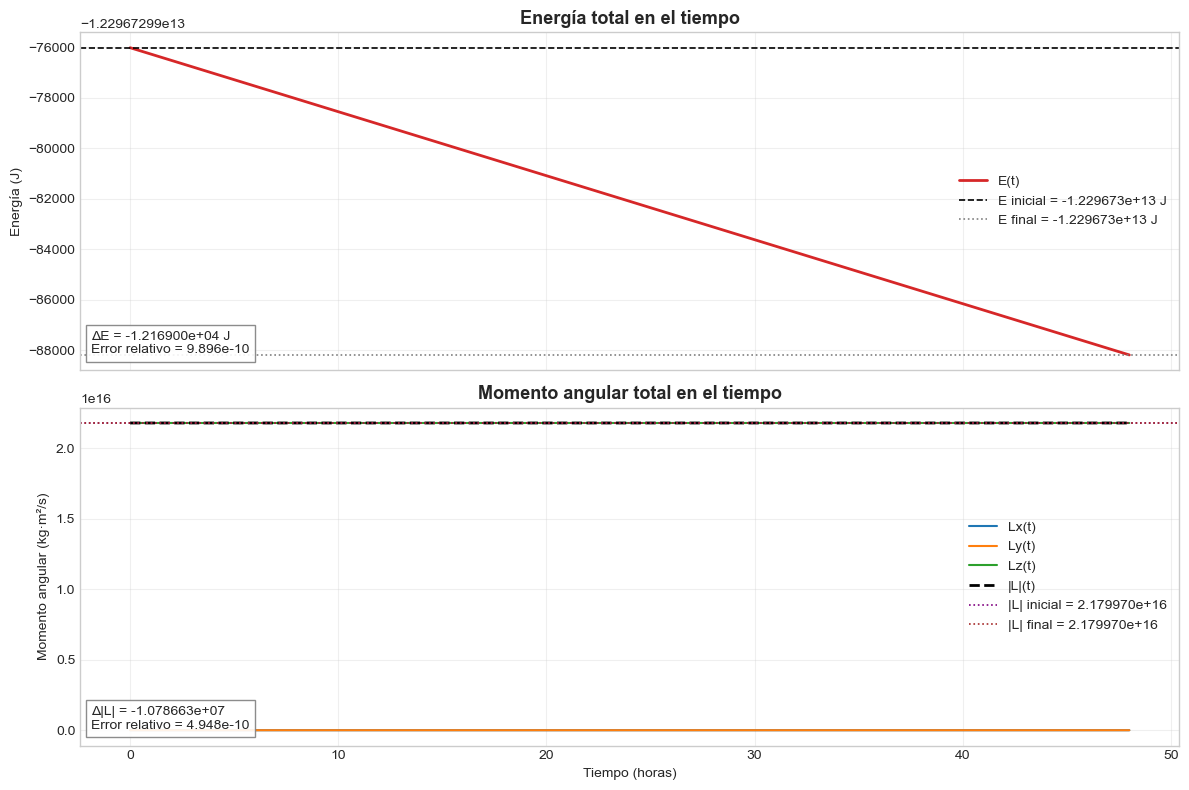

===== MÉTRICAS NUMÉRICAS =====
E inicial          = -1.2296729976e+13 J
E final            = -1.2296729988e+13 J
ΔE                 = -1.2168996094e+04 J
Error relativo E   = 9.8961236991e-10

|L| inicial        = 2.1799702057e+16 kg·m²/s
|L| final          = 2.1799702046e+16 kg·m²/s
Δ|L|               = -1.0786628000e+07 kg·m²/s
Error relativo |L| = 4.9480621211e-10


In [23]:
# Energía y momento angular + métricas numéricas claras
#Se calcula la variación de energía durante toda la simulación
E0 = E[0] #energía inicial
Ef = E[-1] #energía final
dE = Ef - E0 #diferencia entre ambas
rel_dE = abs(dE) / abs(E0) #error relativo , magnitud adimensional que mide el cambio respecto al valor inicial

#Se realiza el mismo análisis para la magnitud del momento angular total
L0 = Lnorm[0]
Lf = Lnorm[-1]
dL = Lf - L0
rel_dL = abs(dL) / abs(L0)

#Se crea una figura con dos paneles: evolución temporal de la energía y evolución del momento angular.
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Energía ---
ax[0].plot(t/3600, E, color="tab:red", lw=2, label="E(t)") #Se grafica la energía total del sistema en función del tiempo
ax[0].axhline(E0, color="black", ls="--", lw=1.2, label=f"E inicial = {E0:.6e} J")
ax[0].axhline(Ef, color="gray", ls=":", lw=1.2, label=f"E final = {Ef:.6e} J")
ax[0].set_title("Energía total en el tiempo", fontsize=13, weight="bold")
ax[0].set_ylabel("Energía (J)")
ax[0].grid(alpha=0.3)
ax[0].legend(loc="best")
ax[0].text(
    0.01, 0.05,
    f"ΔE = {dE:.6e} J\nError relativo = {rel_dE:.3e}",  #El recuadro muestra cuantitativamente la diferencia entre los valores inicial y fina
    transform=ax[0].transAxes,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray")
)

# Se representan las componentes del momento angularen x, y , z.
ax[1].plot(t/3600, Lx, label="Lx(t)")
ax[1].plot(t/3600, Ly, label="Ly(t)")
ax[1].plot(t/3600, Lz, label="Lz(t)")
ax[1].plot(t/3600, Lnorm, "--", color="black", lw=2, label="|L|(t)")
ax[1].axhline(L0, color="purple", ls=":", lw=1.2, label=f"|L| inicial = {L0:.6e}")
ax[1].axhline(Lf, color="brown", ls=":", lw=1.2, label=f"|L| final = {Lf:.6e}")
ax[1].set_title("Momento angular total en el tiempo", fontsize=13, weight="bold")
ax[1].set_xlabel("Tiempo (horas)")
ax[1].set_ylabel("Momento angular (kg·m²/s)")
ax[1].grid(alpha=0.3)
ax[1].legend(loc="best")
ax[1].text(
    0.01, 0.05,
    f"Δ|L| = {dL:.6e}\nError relativo = {rel_dL:.3e}",
    transform=ax[1].transAxes,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray")
)

plt.tight_layout()
plt.show()

print("===== MÉTRICAS NUMÉRICAS =====")
print(f"E inicial          = {E0:.10e} J")
print(f"E final            = {Ef:.10e} J")
print(f"ΔE                 = {dE:.10e} J")
print(f"Error relativo E   = {rel_dE:.10e}")
print()
print(f"|L| inicial        = {L0:.10e} kg·m²/s")
print(f"|L| final          = {Lf:.10e} kg·m²/s")
print(f"Δ|L|               = {dL:.10e} kg·m²/s")
print(f"Error relativo |L| = {rel_dL:.10e}")


<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Resultados principales</h3>

<h4 style="margin: 10px 0 6px; color:#1a1a1a;">1) Órbita en el plano $x-y$</h4>
La trayectoria del satélite alrededor de la Tierra es prácticamente circular.  
Los puntos de inicio y fin muestran el avance orbital durante la ventana de simulación.

<h4 style="margin: 10px 0 6px; color:#1a1a1a;">2) Registros temporales de posición y velocidad</h4>
<ul>
  <li>$x(t)$ y $y(t)$ presentan comportamiento periódico sinusoidal.</li>
  <li>$z(t)\approx 0$, indicando órbita en el plano.</li>
  <li>$|v|(t)$ permanece casi constante (aprox. $7.66\ \text{km/s}$), consistente con una órbita estable.</li>
</ul>

<h4 style="margin: 10px 0 6px; color:#1a1a1a;">3) Estabilidad física (energía y momento angular)</h4>

<b>Métricas numéricas obtenidas:</b>
<ul>
  <li>$E_{inicial} = -1.2296729976\times10^{13}\,\text{J}$</li>
  <li>$E_{final} = -1.2296729988\times10^{13}\,\text{J}$</li>
  <li>$\Delta E = -1.2168996094\times10^{4}\,\text{J}$</li>
</ul>

<b>Error relativo en energía:</b>
$$
\frac{|\Delta E|}{|E_{inicial}|}=9.8961236991\times10^{-10}
$$

<ul>
  <li>$|L|_{inicial} = 2.1799702057\times10^{16}\,\text{kg}\cdot \text{m}^2/\text{s}$</li>
  <li>$|L|_{final} = 2.1799702046\times10^{16}\,\text{kg}\cdot \text{m}^2/\text{s}$</li>
  <li>$\Delta |L| = -1.0786628\times10^{7}\,\text{kg}\cdot \text{m}^2/\text{s}$</li>
</ul>

<b>Error relativo en momento angular:</b>
$$
\frac{|\Delta |L||}{|L|_{inicial}}=4.9480621211\times10^{-10}
$$

<h3 style="margin: 14px 0 6px; color: #c2185b;">💖 Interpretación</h3>
Los errores relativos de energía y momento angular son del orden de $10^{-10}$, lo que indica alta estabilidad numérica para el paso de integración seleccionado.

<h3 style="margin: 14px 0 6px; color: #c2185b;">💖 Conclusión de Fase II</h3>
La implementación modular del solver y la propagación orbital fueron exitosas.  
El sistema reproduce una órbita estable y conserva adecuadamente invariantes físicos, por lo que queda listo para avanzar a la Fase III.

</div>